# **10x Genomics Spatial Methods**

# Analyze Xenium data

## 1. Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Mounts Google Drive in Colab so the Xenium dataset can be loaded from your Drive.

## 2. Import Libraries

In [ ]:
import spatialdata as sd
from spatialdata_io import xenium

import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import squidpy as sq

Imports the packages needed for Xenium data loading, QC, preprocessing, clustering, plotting, and spatial analysis.

## 3. Set File Paths

In [ ]:
xenium_path = "/content/drive/MyDrive/Xenium"
zarr_path = "/content/drive/MyDrive/Xenium.zarr"

Defines the path to the Xenium dataset.

## 4. Load Xenium Data

In [ ]:
sdata = xenium(xenium_path)

/tmp/ipykernel_3159/1221898808.py:1: DeprecationWarning: The default value of `cells_as_circles` will change to `False` in the next release. Please pass `True` explicitly to maintain the current behavior.
  sdata = xenium(xenium_path)
/usr/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


WARNING  The `feature_key` column feature_name is categorical with unknown categories. Please ensure the categories
         are known before calling `PointsModel.parse()` to avoid significant performance implications due to the   
         need for dask to compute the categories. If you did not use PointsModel.parse() explicitly in your code   
         (e.g. this message is coming from a reader in `spatialdata_io`), please report this finding.              


Loads the Xenium output into a SpatialData object containing spatial elements and the expression table.

## 5. Extract AnnData Table

In [ ]:
adata = sdata.tables["table"]
adata

AnnData object with n_obs × n_vars = 162254 × 377
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'z_level', 'nucleus_count', 'cell_labels'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'

Retrieves the main cell-by-gene expression table as an AnnData object.

## 6. View Cell Metadata

In [ ]:
adata.obs

,cell_id,transcript_counts,control_probe_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,cell_area,nucleus_area,region,z_level,nucleus_count,cell_labels
0,aaaadpbp-1,0,0,0,0,0,0,68.456877,NaN,cell_circles,0.0,0.0,1
1,aaaaficg-1,19,0,0,0,0,19,49.130002,21.268595,cell_circles,0.0,1.0,2
2,aaabbaka-1,53,0,0,0,0,53,119.618911,74.778753,cell_circles,0.0,1.0,3
3,aaabbjoo-1,29,0,0,0,0,29,94.241097,59.109533,cell_circles,0.0,1.0,4
4,aaablchg-1,42,0,0,1,0,43,120.341411,52.426408,cell_circles,0.0,1.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
162249,ojaaphhh-1,3,0,0,0,0,3,26.913126,11.153594,cell_circles,5.0,1.0,162250
162250,ojabeldf-1,6,0,0,0,0,6,5.418750,5.418750,cell_circles,7.0,1.0,162251
162251,ojacfbid-1,0,0,0,0,0,0,6.502500,6.502500,cell_circles,5.0,1.0,162252
162252,ojacfhhg-1,2,0,0,0,0,2,7.089532,7.089532,cell_circles,5.0,1.0,162253


Shows per-cell metadata such as transcript counts, cell area, and control counts.

## 7. View Spatial Coordinates

In [ ]:
adata.obsm["spatial"]

array([[ 206.08981323, 1495.89819336],
       [ 201.76582336, 1816.21081543],
       [ 179.02450562, 2167.25390625],
       ...,
       [4463.31298828, 1576.60400391],
       [4619.91552734, 1454.3223877 ],
       [4620.28125   , 1528.10766602]])

Displays the spatial coordinates for each cell, used in spatial plots and graph construction.

## 8. Compute QC Metrics

In [ ]:
sc.pp.calculate_qc_metrics(adata, percent_top=(10, 20, 50, 150), inplace=True)

Calculates standard quality-control metrics like total counts and number of detected genes.

## 9. Check Negative Controls

In [ ]:
cprobes = (
    adata.obs["control_probe_counts"].sum() / adata.obs["total_counts"].sum() * 100
)
cwords = (
    adata.obs["control_codeword_counts"].sum() / adata.obs["total_counts"].sum() * 100
)
print(f"Negative DNA probe count % : {cprobes}")
print(f"Negative decoding count % : {cwords}")

Negative DNA probe count % : 0.0042798755460108405
Negative decoding count % : 0.0018622359246001363


Measures the percentage of counts from negative control probes and codewords to assess background noise.

## 10. Plot QC Distributions

<Axes: title={'center': 'Nucleus ratio'}, ylabel='Count'>

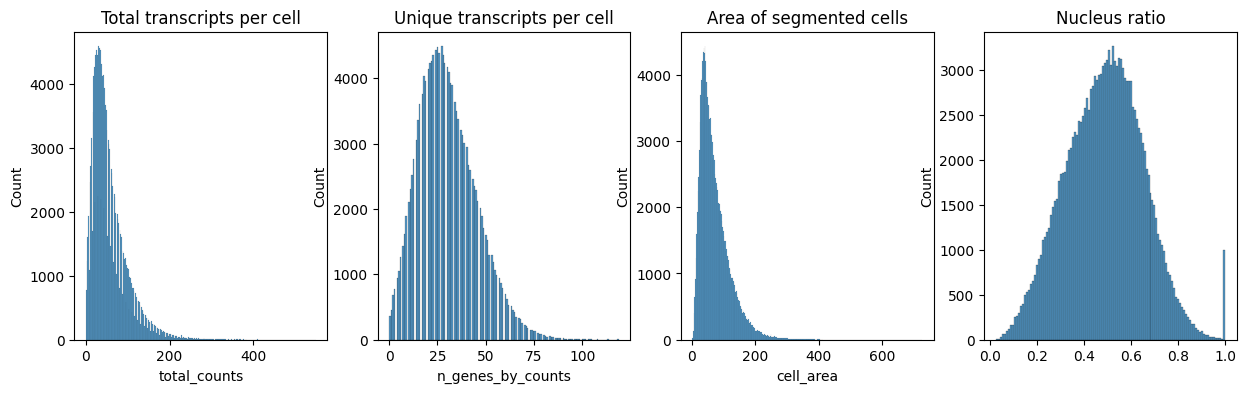

In [ ]:
fig, axs = plt.subplots(1, 4, figsize=(15, 4))

axs[0].set_title("Total transcripts per cell")
sns.histplot(
    adata.obs["total_counts"],
    kde=False,
    ax=axs[0],
)

axs[1].set_title("Unique transcripts per cell")
sns.histplot(
    adata.obs["n_genes_by_counts"],
    kde=False,
    ax=axs[1],
)


axs[2].set_title("Area of segmented cells")
sns.histplot(
    adata.obs["cell_area"],
    kde=False,
    ax=axs[2],
)

axs[3].set_title("Nucleus ratio")
sns.histplot(
    adata.obs["nucleus_area"] / adata.obs["cell_area"],
    kde=False,
    ax=axs[3],
)

Plots key QC distributions to inspect sequencing depth, gene diversity, segmentation size, and nucleus-to-cell area ratio.

## 11. Filter Cells and Genes

In [ ]:
sc.pp.filter_cells(adata, min_counts=10)
sc.pp.filter_genes(adata, min_cells=5)

Removes very low-count cells and rarely detected genes to reduce noise.

## 12. Normalize and Cluster

In [ ]:
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, inplace=True)
sc.pp.log1p(adata)
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.tl.leiden(adata)

/tmp/ipykernel_6117/4193936636.py:7: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata)


Stores counts, normalizes the data, applies log transformation, reduces dimensionality, builds a neighbor graph, computes UMAP, and identifies clusters.



## 13. Visualize UMAP

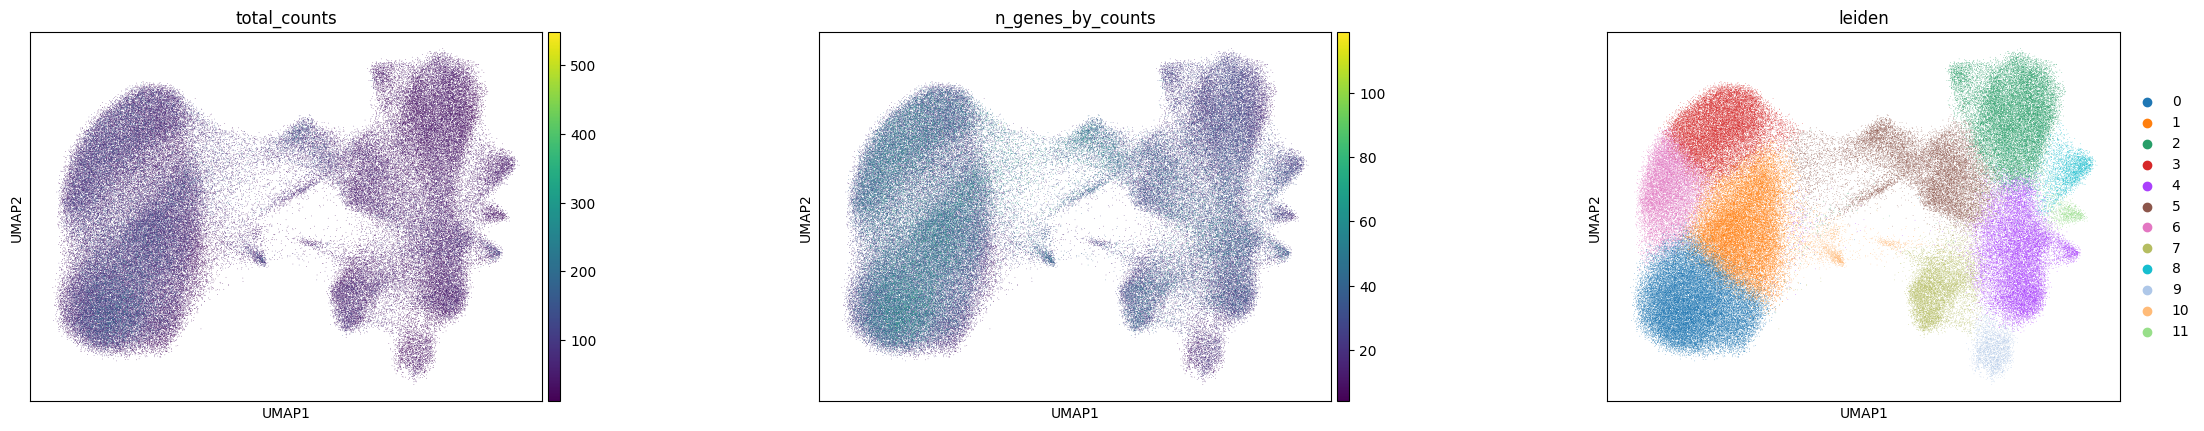

In [ ]:
sc.pl.umap(
    adata,
    color=[
        "total_counts",
        "n_genes_by_counts",
        "leiden",
    ],
    wspace=0.4,
)

Plots cells in UMAP space colored by QC metrics and cluster labels.

## 14. Plot Spatial Clusters

/usr/local/lib/python3.12/dist-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


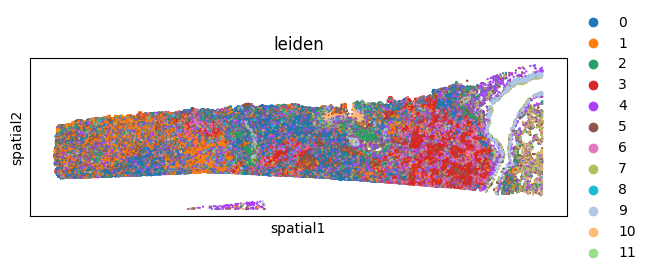

In [ ]:
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    shape=None,
    color=[
        "leiden",
    ],
    wspace=0.4,
)

Shows how Leiden clusters are distributed across the tissue.

## 15. Build Spatial Neighbor Graph

In [ ]:
sq.gr.spatial_neighbors(adata, coord_type="generic", delaunay=True)

INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


Creates a spatial graph from cell coordinates using Delaunay triangulation.

## 16. Compute Centrality Scores

In [ ]:
sq.gr.centrality_scores(adata, cluster_key="leiden")

Calculates graph-based centrality measures for each cluster.

## 17. Plot Centrality Scores

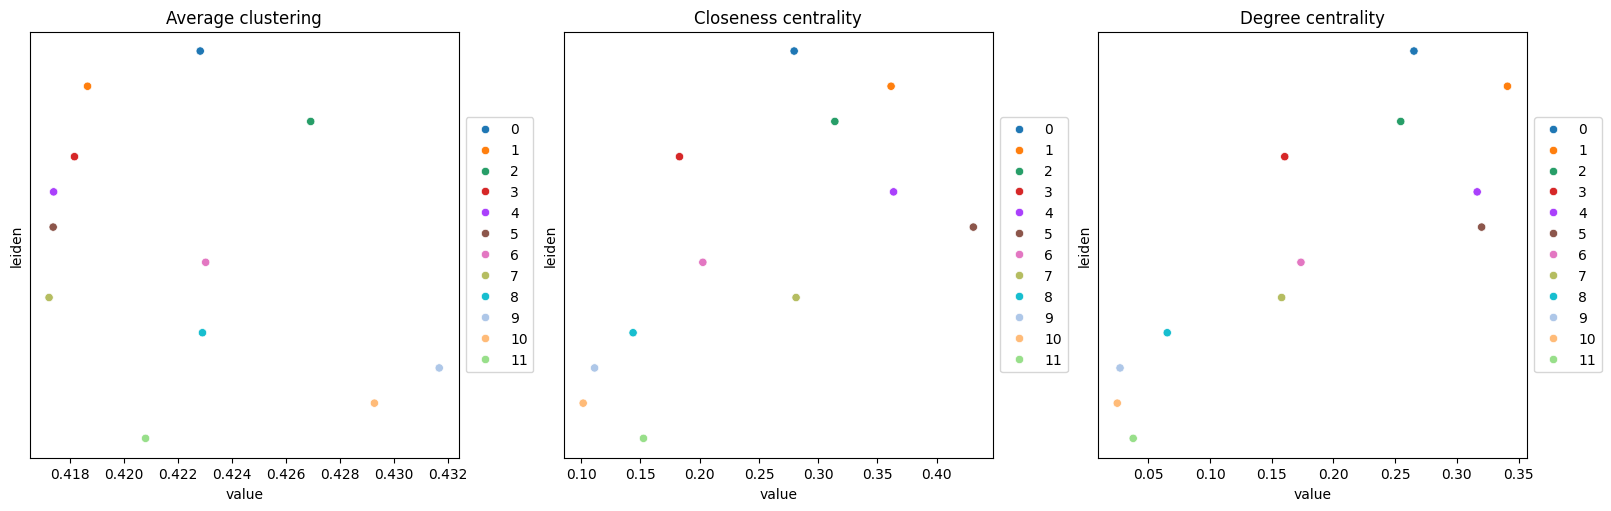

In [ ]:
sq.pl.centrality_scores(adata, cluster_key="leiden", figsize=(16, 5))

Visualizes spatial centrality metrics across clusters.

## 18. Create a Subsample

In [ ]:
sdata.tables["subsample"] = sc.pp.subsample(adata, fraction=0.5, copy=True)

Creates a random 50% subset of cells for faster spatial analyses.

## 19. Access the Subsample

In [ ]:
adata_subsample = sdata.tables["subsample"]

Stores the subsampled dataset in a separate variable.

## 20. Co-occurrence Analysis

/usr/local/lib/python3.12/dist-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


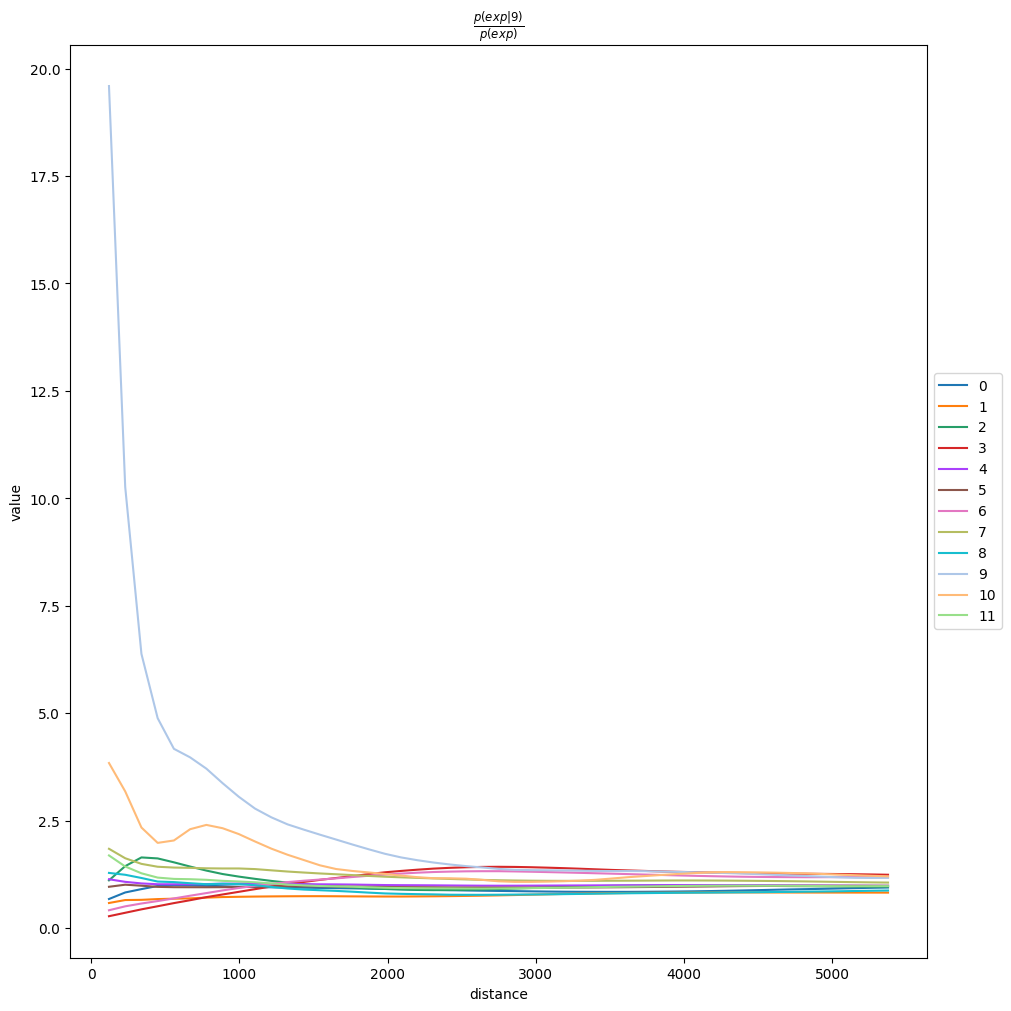

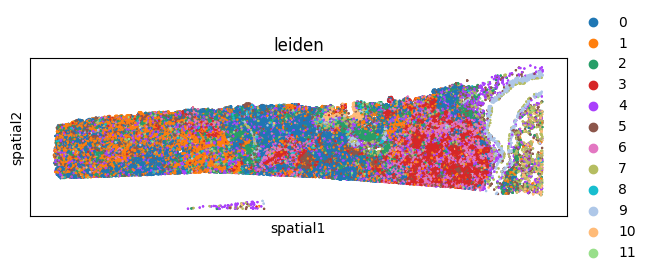

In [ ]:
sq.gr.co_occurrence(
    adata_subsample,
    cluster_key="leiden",
)
sq.pl.co_occurrence(
    adata_subsample,
    cluster_key="leiden",
    clusters="9",
    figsize=(10, 10),
)
sq.pl.spatial_scatter(
    adata_subsample,
    color="leiden",
    shape=None,
    size=2,
)

Computes and plots how often clusters appear near one another, then visualizes cluster positions in tissue space.



## 21. Neighborhood Enrichment

In [ ]:
sq.gr.nhood_enrichment(adata, cluster_key="leiden")

  0%|          | 0/1000 [00:00<?, ?/s]

Tests whether certain clusters are spatially enriched or depleted in each other’s neighborhoods.

## 22. Plot Neighborhood Enrichment

/usr/local/lib/python3.12/dist-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


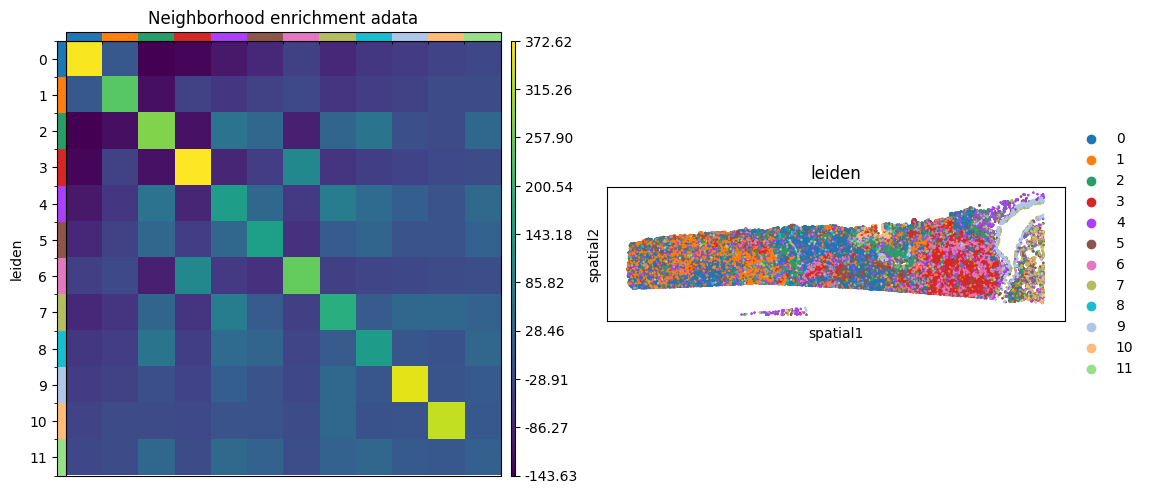

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 7))
sq.pl.nhood_enrichment(
    adata,
    cluster_key="leiden",
    figsize=(8, 8),
    title="Neighborhood enrichment adata",
    ax=ax[0],
)
sq.pl.spatial_scatter(adata_subsample, color="leiden", shape=None, size=2, ax=ax[1])

Displays the neighborhood enrichment heatmap alongside the spatial distribution of clusters.

## 23. Spatial Autocorrelation

In [ ]:
sq.gr.spatial_neighbors(adata_subsample, coord_type="generic", delaunay=True)
sq.gr.spatial_autocorr(
    adata_subsample,
    mode="moran",
    n_perms=100,
    n_jobs=1,
)
adata_subsample.uns["moranI"].head(10)

INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


  0%|          | 0/100 [00:00<?, ?/s]

,I,pval_norm,var_norm,pval_z_sim,pval_sim,var_sim,pval_norm_fdr_bh,pval_z_sim_fdr_bh,pval_sim_fdr_bh
C20orf85,0.574287,0.0,0.000004,0.0,0.009901,0.000006,0.0,0.0,0.011415
CYP2B6,0.542362,0.0,0.000004,0.0,0.009901,0.000006,0.0,0.0,0.011415
MALL,0.491696,0.0,0.000004,0.0,0.009901,0.000006,0.0,0.0,0.011415
MS4A1,0.454081,0.0,0.000004,0.0,0.009901,0.000006,0.0,0.0,0.011415
MYC,0.448337,0.0,0.000004,0.0,0.009901,0.000006,0.0,0.0,0.011415
C1orf194,0.438038,0.0,0.000004,0.0,0.009901,0.000005,0.0,0.0,0.011415
EPCAM,0.430572,0.0,0.000004,0.0,0.009901,0.000006,0.0,0.0,0.011415
CAPN8,0.429334,0.0,0.000004,0.0,0.009901,0.000006,0.0,0.0,0.011415
TCIM,0.366845,0.0,0.000004,0.0,0.009901,0.000006,0.0,0.0,0.011415
MYH11,0.361113,0.0,0.000004,0.0,0.009901,0.000006,0.0,0.0,0.011415


Computes Moran’s I to find genes with spatially patterned expression.

## 24. Plot Selected Genes Spatially

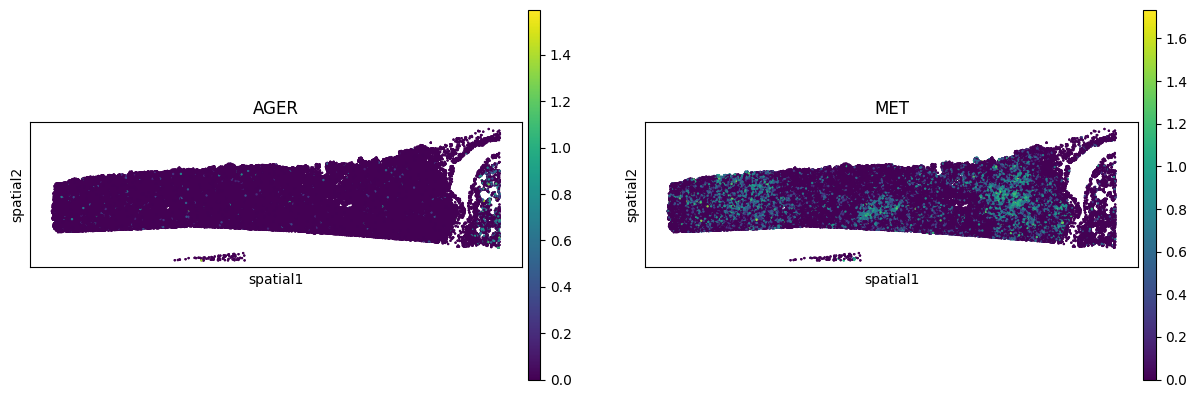

In [ ]:
sq.pl.spatial_scatter(
    adata_subsample,
    library_id="spatial",
    color=[
        "AGER",
        "MET",
    ],
    shape=None,
    size=2,
    img=False,
)

Plots the spatial expression of selected genes to inspect where they localize in the tissue.

## 25. Reload Data and Plot Genes One by One

/usr/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


WARNING  The `feature_key` column feature_name is categorical with unknown categories. Please ensure the categories
         are known before calling `PointsModel.parse()` to avoid significant performance implications due to the   
         need for dask to compute the categories. If you did not use PointsModel.parse() explicitly in your code   
         (e.g. this message is coming from a reader in `spatialdata_io`), please report this finding.              


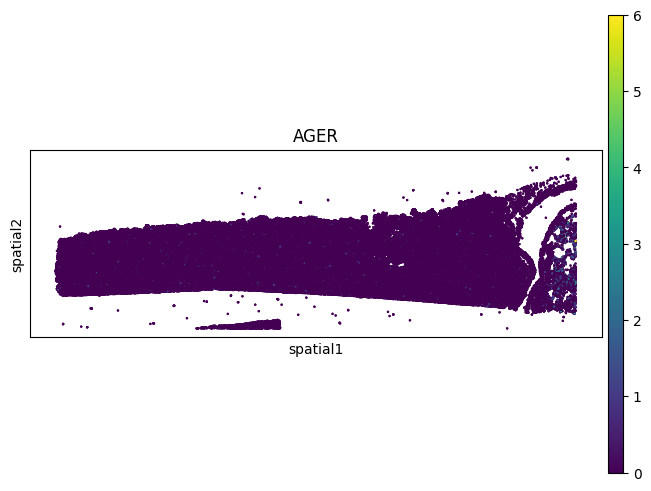

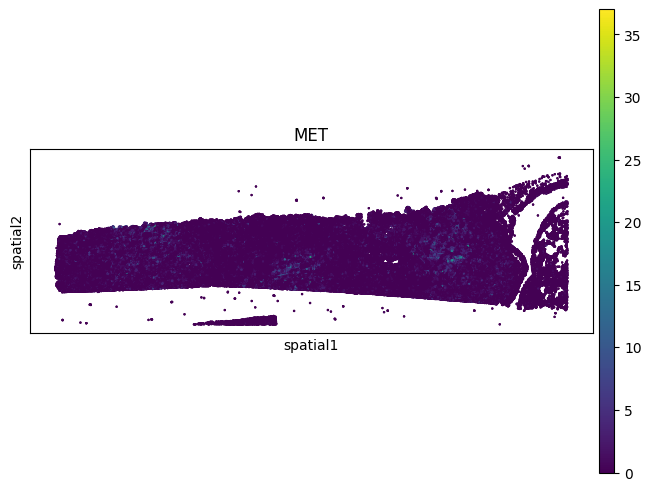

In [ ]:
from spatialdata_io import xenium
import squidpy as sq

adata = xenium("/content/drive/MyDrive/Xenium", cells_as_circles=True).tables["table"]

for gene in ["AGER", "MET"]:
    if gene in adata.var_names:
        sq.pl.spatial_scatter(
            adata,
            color=gene,
            shape=None,
            size=2,
            img=False,
        )



Reloads the Xenium data with cells_as_circles=True and plots each selected gene individually if it is present.